# Clasificador de SMS: ¿SPAM o HAM (Legítimo)?

En esta práctica vamos a construir un modelo de Machine Learning capaz de analizar texto y clasificar si un mensaje (SMS) es correo basura (**SPAM**) o un mensaje legítimo (**HAM**).

## 1. Importación de Librerías
Para empezar, necesitamos importar las herramientas que usaremos. Ya te proporcionamos las básicas de manipulación de datos. Más adelante tendrás que importar los algoritmos y métricas específicas.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
import spacy

import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Descargas necesarias de NLTK
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

## 2. Carga de Datos
Vamos a cargar nuestro conjunto de datos. Suele ser un archivo CSV que contiene una columna con la etiqueta (spam o ham) y otra con el texto del mensaje.
Tu tarea es leer este archivo y explorar sus primeros registros.

In [3]:
df = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'message'])
df.info()

# TODO: Muestra las primeras 5 filas del dataframe para entender su estructura
print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 3. Exploración de Datos
Antes de procesar el texto y entrenar el modelo, debemos entender nuestros datos. Vamos a ver si el conjunto de datos está desbalanceado (es decir, si hay muchos más mensajes legítimos que spam) y a crear una variable útil.

label
ham     4825
spam     747
Name: count, dtype: int64


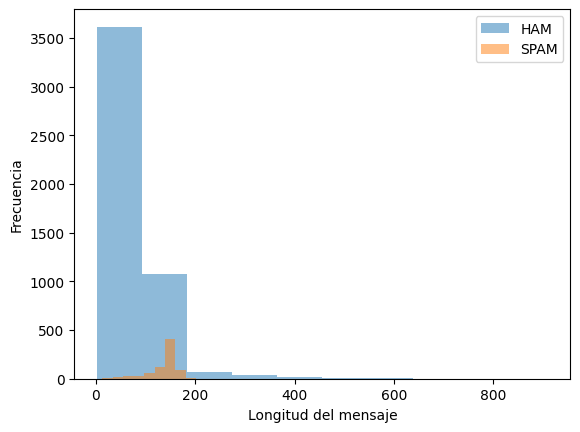

In [10]:
# TODO: Muestra un recuento de cuántos mensajes hay de cada clase (SPAM vs HAM).
# Pista: usa el método value_counts() en la columna de las etiquetas.
print(df["label"].value_counts())

# 3.1 Creación de Características (Feature Engineering)
# A veces la longitud del mensaje es un buen indicador de si es SPAM.
# TODO: Crea una nueva columna llamada 'longitud' que contenga el número de caracteres de cada mensaje de texto.
df['longitud'] = df["message"].apply(len)

# TODO: Muestra un histograma para ver la distribución de la longitud de los mensajes según su clase.
plt.hist(df[df['label'] == 'ham']['longitud'], alpha=0.5, label='HAM')
plt.hist(df[df['label'] == 'spam']['longitud'], alpha=0.5, label='SPAM')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


## 4. Preprocesamiento de Texto
¡Esta es la fase clave en el Procesamiento de Lenguaje Natural (NLP)! Los algoritmos matemáticos no entienden palabras directamente, así que debemos limpiar y estandarizar el texto antes de convertirlo en números.

Tus objetivos para procesar cada mensaje:
1. **Limpieza:** Convertir todo a minúsculas y quitar signos de puntuación.
2. **Tokenización:** Dividir el mensaje en palabras sueltas (tokens).
3. **Stopwords:** Eliminar palabras vacías (como "el", "de", "y") que no aportan significado diferencial.
4. **Lematización:** Convertir las palabras a su raíz o forma base (ej. "corriendo" -> "correr").

In [18]:
import string
import nltk
# Es posible que necesites descargar estos complementos si corres esto por primera vez:
# nltk.download('stopwords')
# nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def procesar_mensaje(mensaje):
    """
    Función que recibe un mensaje de texto original y devuelve el texto limpio y lematizado.
    """
    # TODO 1: Eliminar signos de puntuación y pasar todo el texto a minúsculas
    mensaje = re.sub(r'[^\w\s]', '', mensaje).lower()

    # TODO 2: Tokenizar el mensaje (separar la frase en una lista de palabras)
    doc = nltk.word_tokenize(mensaje)

    # TODO 3: Eliminar las stopwords (filtrar la lista de palabras)
    stop_words = set(stopwords.words())
    tokens_filtrados = []
    for token in doc:
        if token not in stop_words:
            # TODO 4: Lematizar las palabras resultantes
            tokens_filtrados.append(lemmatizer.lemmatize(token))
    
    # TODO 5: Unir las palabras procesadas de nuevo en una sola cadena de texto separada por espacios y retornarla
    return " ".join(tokens_filtrados)

# TODO: Aplica tu función a la columna de mensajes y guarda el resultado en una nueva columna llamada 'texto_limpio'
df['texto_limpio'] = df["message"].apply(procesar_mensaje)


## 5. Vectorización
Con el texto limpio, vamos a transformarlo en una matriz numérica. Utilizaremos técnicas como **Bag of Words** (`CountVectorizer`) o **TF-IDF** (`TfidfVectorizer`) para que nuestro modelo pueda interpretar el peso de cada palabra.

In [19]:
# TODO: Importa el vectorizador elegido de sklearn.feature_extraction.text
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: Inicializa el vectorizador
vectorizador = TfidfVectorizer()

# TODO: Ajusta el vectorizador a tu 'texto_limpio' y transforma los datos. Guárdalo en la variable 'X'
X = vectorizador.fit_transform(df['texto_limpio'])

# TODO: Define tu variable objetivo guardando las etiquetas (spam/ham) en la variable 'y'
y = df['label']

## 6. Construcción del Modelo
Ahora vamos a dividir nuestros datos en un conjunto de **Entrenamiento** (para que el modelo aprenda) y otro de **Prueba** (para ver qué tan bien aprendió). Después, elegiremos un modelo de clasificación para entrenarlo. Un modelo clásico para NLP es Naive Bayes.

In [20]:
# TODO: Importa train_test_split de sklearn.model_selection
from sklearn.model_selection import train_test_split

# TODO: Divide los datos (X, y) en X_train, X_test, y_train, y_test
# (Te sugerimos usar un 80% de los datos para entrenar y un 20% para test).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Importa el modelo clasificador que desees (ej. MultinomialNB de sklearn.naive_bayes)
from sklearn.naive_bayes import MultinomialNB

# TODO: Inicializa el modelo y entrénalo usando los datos de entrenamiento (X_train, y_train)
modelo = MultinomialNB()
modelo.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## 7. Evaluación del Modelo
¿Qué tan confiable es nuestro filtro de SPAM? Vamos a predecir las etiquetas para los mensajes que el modelo no ha visto (`X_test`) y a evaluar su rendimiento usando diferentes métricas.

In [ ]:
# TODO: Utiliza tu modelo entrenado para predecir las etiquetas de X_test
# predicciones = ...

# TODO: Importa métricas de evaluación (accuracy_score, confusion_matrix, classification_report de sklearn.metrics)

# TODO: Muestra la precisión global (Accuracy) del modelo

# TODO: Imprime la Matriz de Confusión. ¿Tu modelo se equivoca más marcando correos legítimos como SPAM, o dejando pasar SPAM?

# TODO: Muestra el Reporte de Clasificación (Classification Report) para ver el Precision y Recall de ambas clases.


#8. ¿Probamos con otro modelo?